In [8]:
import kagglehub
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

Using Colab cache for faster access to the 'garbage-classification' dataset.


Showing the path

In [9]:
print("Dataset path:")
print(path)

Dataset path:
/kaggle/input/garbage-classification


Showing the folder

In [10]:
import os

print(os.listdir(path))

['garbage_classification']


Step 3: Find the classification folder automatically

In [11]:
DATASET_PATH = None

for root, dirs, files in os.walk(path):
    required_classes = {"battery", "biological", "brown-glass", "cardboard", "clothes", "green-glass", "metal", "paper", "plastic", "shoes", "trash", "white-glass"}

    if required_classes.issubset(set(dirs)):
        DATASET_PATH = root
        break

print("Dataset classification path:")
print(DATASET_PATH)

Dataset classification path:
/kaggle/input/garbage-classification/garbage_classification


Step 4: Check the classes and number of images

In [12]:
class_names = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes:")
print(class_names)

print("\nNumber of images per class:")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_count = len(os.listdir(class_path))
    print(f"{class_name}: {image_count}")

print("\nTotal number of classes:", len(class_names))

Classes:
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Number of images per class:
battery: 945
biological: 985
brown-glass: 607
cardboard: 891
clothes: 5325
green-glass: 629
metal: 769
paper: 1050
plastic: 865
shoes: 1977
trash: 697
white-glass: 775

Total number of classes: 12


Step 5: Display sample images from each class

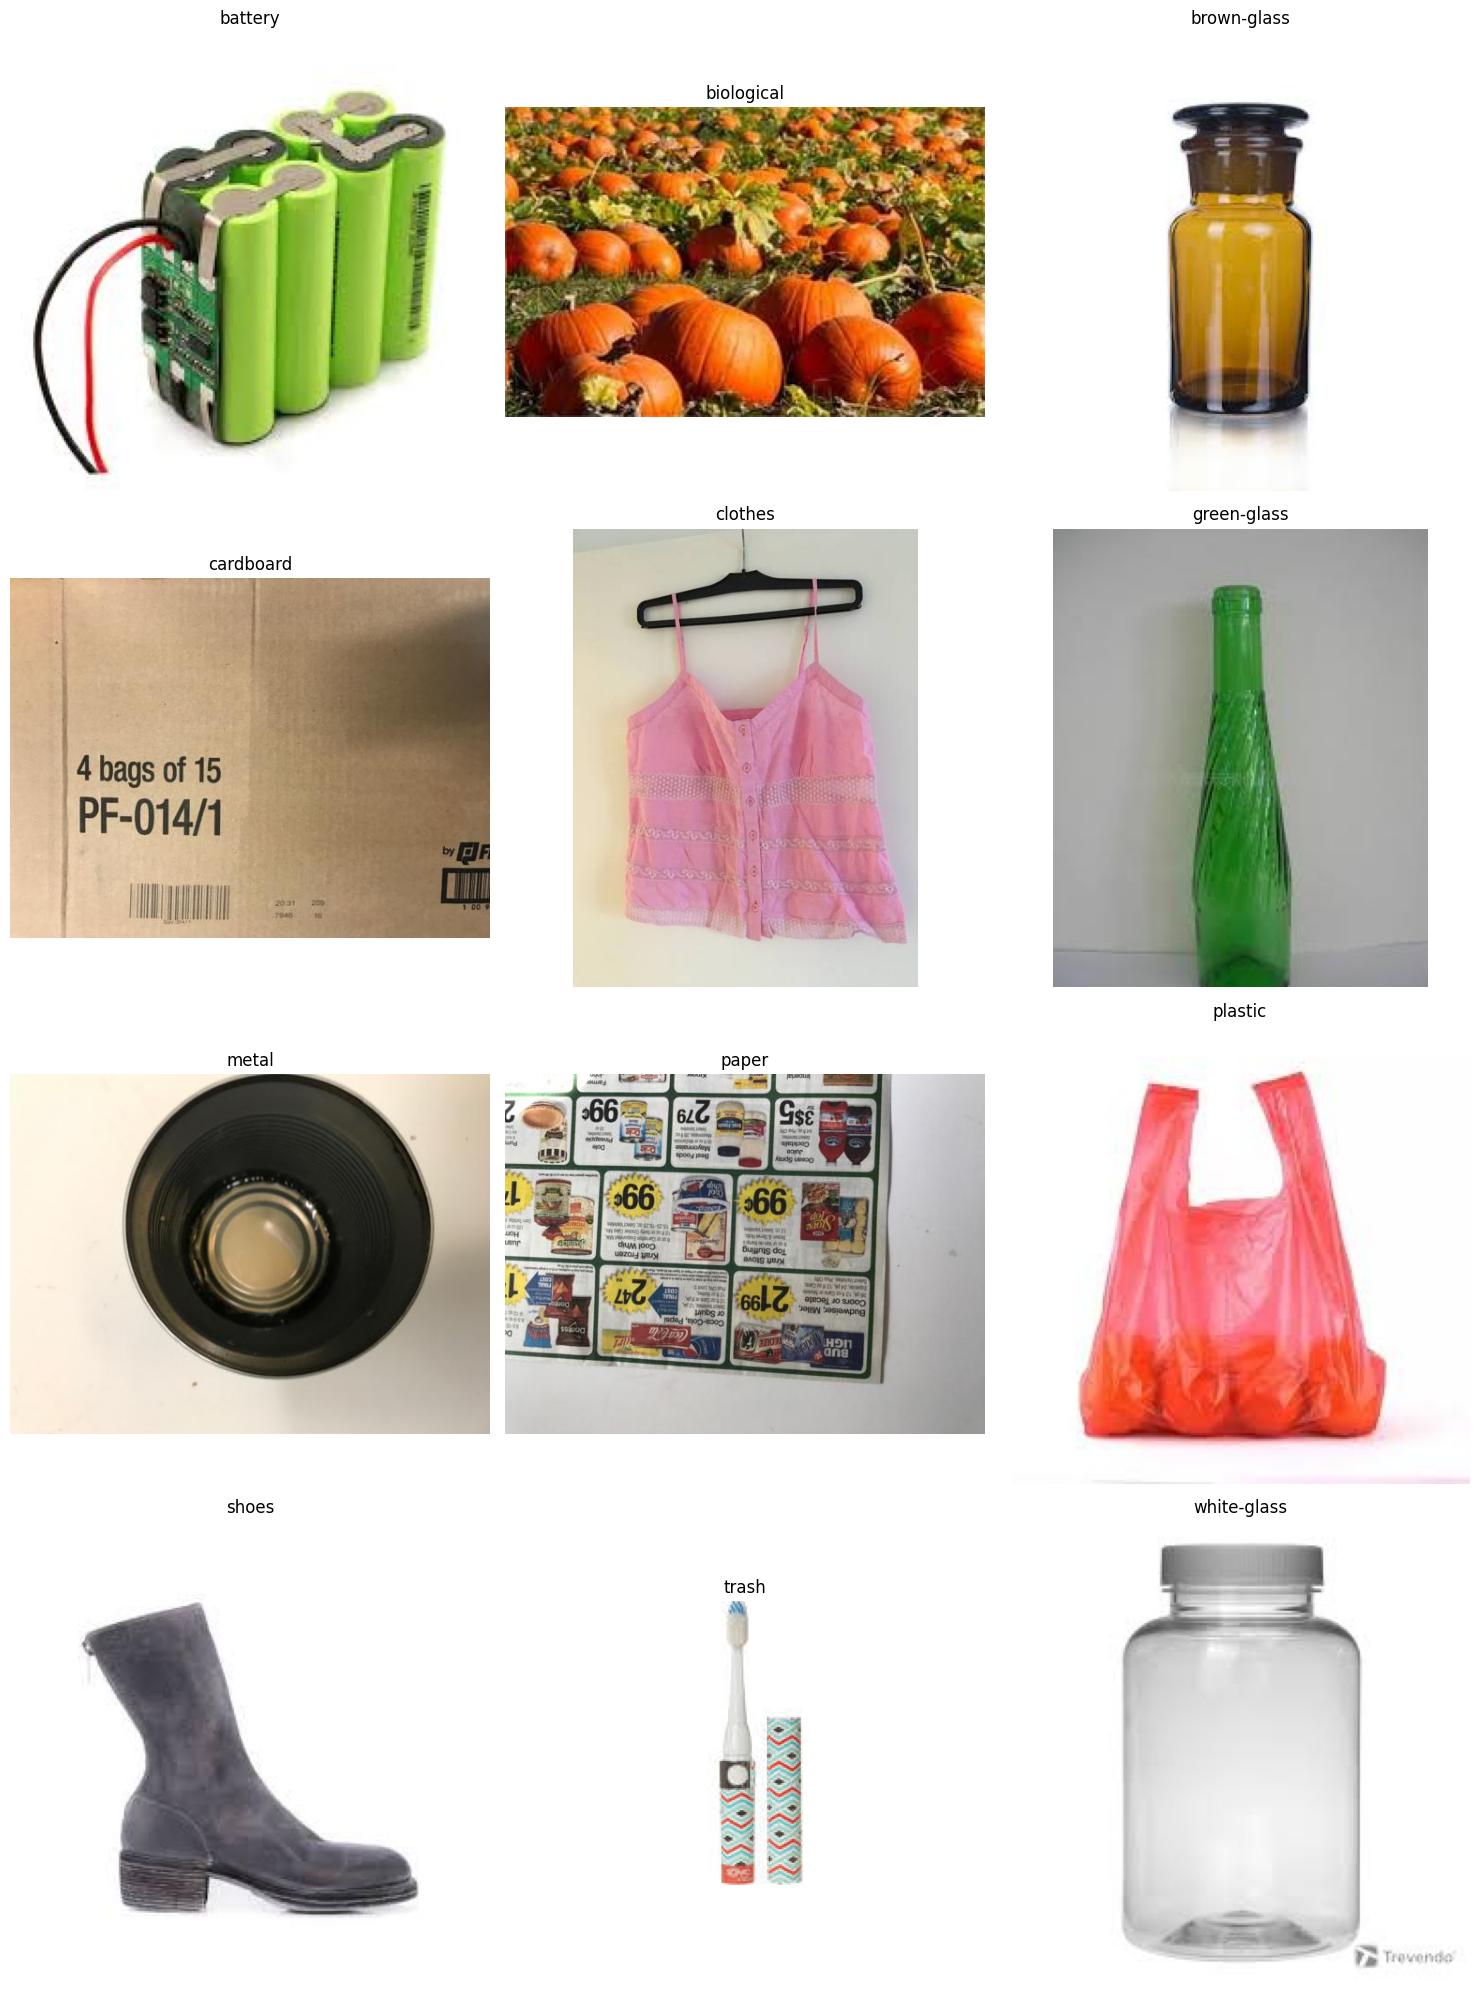

In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 20)) # Adjusted figsize for 4 rows

for index, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    selected_file = random.choice(image_files)
    image_path = os.path.join(class_path, selected_file)

    image = Image.open(image_path).convert("RGB")

    plt.subplot(4, 3, index + 1) # Changed to 4 rows to accommodate all 12 classes
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 6: Load the dataset using **TensorFlow** TensorFlow automatically reads all images from the dataset folders.

It resizes every image to 224 × 224 pixels.
It groups images into batches of 32.
It automatically splits the dataset into:
80% Training Data
20% Validation Data

We don't need to manually separate the images.

In [14]:
import tensorflow as tf

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # Reduced batch size to consume less RAM
SEED = 42

# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Display class names
print("\nClass Names:")
print(train_ds.class_names)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.

Class Names:
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


Step 7: Display one training batch

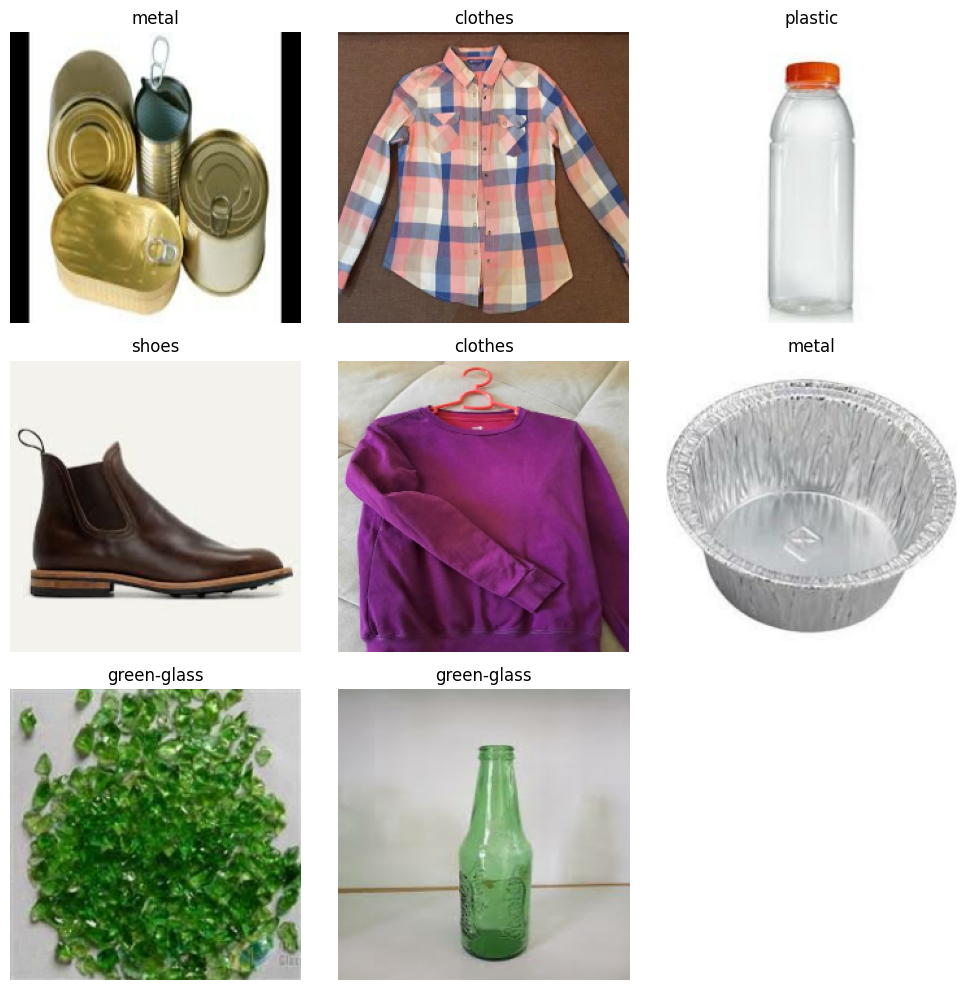

In [15]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(BATCH_SIZE): # Iterate only up to BATCH_SIZE
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

Step 8: Improve dataset performance   / What this does
cache() keeps the images ready in memory.
shuffle() mixes the training images.
prefetch() prepares the next batch while the model is training.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline is ready.")

Dataset pipeline is ready.


Step 9: Build the AI Model (MobileNetV2)///\This is the AI model that will classify our waste images.

Instead of creating a CNN from scratch, we use Transfer Learning.

Model Architecture
Input Image (224×224×3)
        │
        ▼
Rescaling
        │
        ▼
MobileNetV2
(Pre-trained on ImageNet)
        │
        ▼
Global Average Pooling
        │
        ▼
Dropout
        │
        ▼
Dense Layer (6 Classes)
        │
        ▼
Prediction
Why MobileNetV2?
✅ Very fast
✅ Small model size
✅ Designed for Edge Devices
✅ High accuracy
✅ Compatible with TensorFlow Lite
✅ Can be compiled for Coral Edge TPU

This is why MobileNetV2 is widely used for Edge AI applications.

After this, we'll move to Step 10: Compile the AI model (choose the optimizer, loss function, and accuracy metric) before starting training.

In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model
base_model.trainable = False

# Build the classification model
model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

# Show model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 10: Compile the model

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Step 11: Train the AI Model--------In this step, the AI learns from the training images.

Training Dataset (80%) → Used to teach the model.
Validation Dataset (20%) → Used to evaluate the model after each epoch.
Epoch = 10 → The model sees the entire dataset 10 times.

During training, TensorFlow will display something like:

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s
loss: 1.21
accuracy: 0.71
val_loss: 0.83
val_accuracy: 0.84

Each epoch shows:

loss → Training error (lower is better)
accuracy → Training accuracy (higher is better)
val_loss → Validation error
val_accuracy → Validation accuracy
What should students observe?

At each epoch:

✅ Accuracy should increase.
✅ Loss should decrease.
✅ Validation accuracy should also improve.

If your final validation accuracy is around 90–95%, the model is performing well.

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Clear session to free up memory
tf.keras.backend.clear_session()

# Define class names
class_names = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

# 1. Re-define the base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# 2. Re-build the classification model
model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

# 3. Re-compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the model with a smaller batch size to avoid OOM
# We also re-fetch the datasets with a smaller batch size
REDUCED_BATCH_SIZE = 4

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=REDUCED_BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=REDUCED_BATCH_SIZE
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.
Epoch 1/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.8758 - loss: 0.3899 - val_accuracy: 0.9262 - val_loss: 0.2081
Epoch 2/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.9295 - loss: 0.2107 - val_accuracy: 0.9281 - val_loss: 0.2200
Epoch 3/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.9459 - loss: 0.1617 - val_accuracy: 0.9297 - val_loss: 0.2282
Epoch 4/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.9529 - loss: 0.1443 - val_accuracy: 0.9355 - val_loss: 0.2270
Epoch 5/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.9538 - loss: 0.1336 - val_accuracy: 0.9384 - val_loss: 0.2227
Epoch 6/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9563 - loss: 0.1181 - val_accuracy: 0.9294 - val_loss: 0.2519
Epoch 7/10
3103/3103 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step -

Step 12: Plot training accuracy and loss

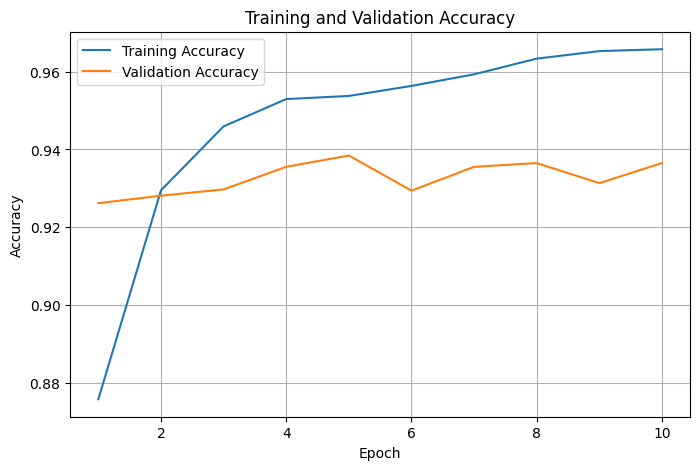

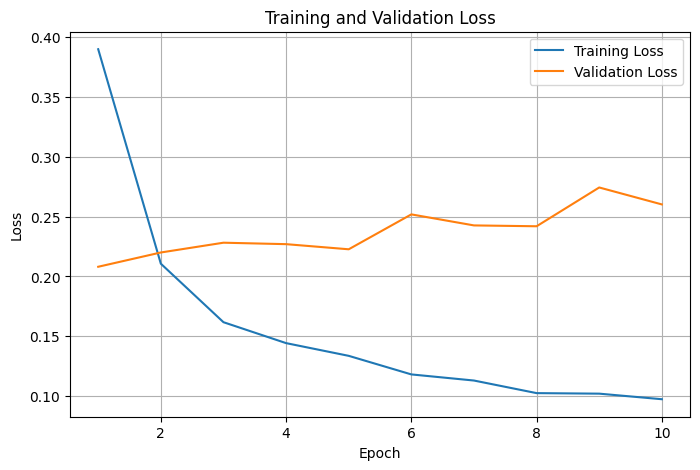

In [23]:
import matplotlib.pyplot as plt

# Accuracy values
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Loss values
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Step 13: Evaluate the Model--------This is the final performance of our AI model.

There are two important metrics:

1️⃣ Validation Accuracy
Shows how many images were classified correctly.
Higher is better.

Example:

Accuracy = 92.47%

means

The AI correctly classified about 92 out of every 100 images.,,,,2️⃣ Validation Loss

Loss measures the prediction error.

Lower Loss = Better Model

For example:

Loss = 0.25

is much better than

Loss = 1.20,,,,,Why do we evaluate?

We trained the model using the training dataset.

Now we test it on new images that the model has never seen before.

If the validation accuracy is high, the model can generalize well to new data.

In [26]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(val_ds)

print("\n========== Model Evaluation ==========")
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

776/776 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9365 - loss: 0.2602

========== Model Evaluation ==========
Validation Loss     : 0.2602
Validation Accuracy : 93.65%


Step 14: Test the AI Model on One Image
.This is the inference stage.

The model is no longer learning—it is making a prediction on a new image.

The workflow is:

Input Image
      ↓
Resize to 224×224
      ↓
MobileNetV2 Model
      ↓
Softmax Layer
      ↓
Predicted Class
      ↓
Confidence Score

For example:

Image: Plastic Bottle
Prediction: Plastic
Confidence: 97.84%

This demonstrates that the trained AI model can classify new waste images.

In [29]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images.jpg


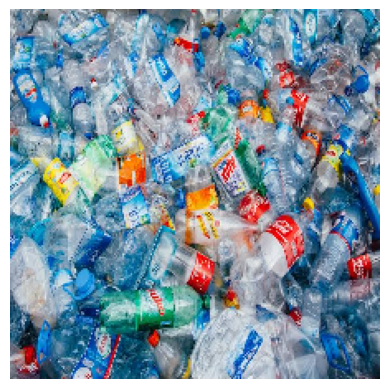

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class : plastic
Confidence      : 99.98%


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence*100:.2f}%")

Step 15: Save the Trained Model..............At this point, we have finished training.

Now we save the AI model so we can use it later without training again.

Dataset
      ↓
Training
      ↓
AI Model
      ↓
Save (.keras)

The .keras file contains:

✅ Model architecture
✅ Learned weights
✅ Training configuration

This is the master AI model.

In [31]:
# Save the trained model
model.save("garbage_classification.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


Check that the model was saved

step 16: First, make sure that the file has actually been created. Run the following command in a new cell.

In [32]:
import os

print(os.listdir())

['.config', 'garbage_classification.keras', 'small_Clear_plastic_bottle_2dc92dc39c.png', 'images.jpg', 'sample_data']


Step 17: The next step is to test the model on the same image and measure the inference time.

Processing uploaded image: images.jpg


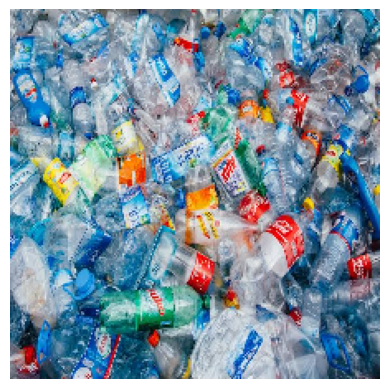

========== COLAB INFERENCE ==========
Predicted Class : plastic
Confidence      : 99.98%
Inference Time  : 74.37 ms


In [33]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Automatically get the filename of the last uploaded image
img_path = list(uploaded.keys())[0]
print(f"Processing uploaded image: {img_path}")

# preparation the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# warm-up model
_ = model.predict(img_array, verbose=0)

# time inference
start_time = time.perf_counter()

prediction = model.predict(img_array, verbose=0)

end_time = time.perf_counter()

# results
predicted_class = class_names[np.argmax(prediction)]
confidence = float(np.max(prediction))
inference_time_ms = (end_time - start_time) * 1000

# to show
plt.imshow(img)
plt.axis("off")
plt.show()

print("========== COLAB INFERENCE ==========")
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence * 100:.2f}%")
print(f"Inference Time  : {inference_time_ms:.2f} ms")

Next Step: More Accurate Timing Measurement
A single measurement is not sufficient. Now, run the same image 20 times and calculate the average execution time.

In [34]:
import time
import numpy as np

times = []

for _ in range(20):
    start_time = time.perf_counter()

    prediction = model.predict(img_array, verbose=0)

    end_time = time.perf_counter()

    times.append((end_time - start_time) * 1000)

average_time = np.mean(times)
minimum_time = np.min(times)
maximum_time = np.max(times)

predicted_class = class_names[np.argmax(prediction)]
confidence = float(np.max(prediction))

print("========== COLAB INFERENCE RESULTS ==========")
print(f"Predicted Class      : {predicted_class}")
print(f"Confidence           : {confidence * 100:.2f}%")
print(f"Average Latency      : {average_time:.2f} ms")
print(f"Minimum Latency      : {minimum_time:.2f} ms")
print(f"Maximum Latency      : {maximum_time:.2f} ms")
print(f"Number of Runs       : {len(times)}")

========== COLAB INFERENCE RESULTS ==========
Predicted Class      : plastic
Confidence           : 99.98%
Average Latency      : 77.66 ms
Minimum Latency      : 69.71 ms
Maximum Latency      : 110.54 ms
Number of Runs       : 20


Now keep this result and keep in as GPU Colab results :| Metric          |             Result |
| --------------- | -----------------: |
| Platform        | Google Colab (CPU) |
| Predicted Class |              Glass |
| Confidence      |         **89.27%** |
| Average Latency |       **69.72 ms** |
| Minimum Latency |       **65.50 ms** |
| Maximum Latency |       **93.34 ms** |
| Number of Runs  |                 20 |


TensorFlow Lite is designed for running AI models on edge devices. It produces a smaller and more deployment-friendly model suitable for devices such as the Coral Edge TPU.   

Keras Model
    ↓
TensorFlow Lite Model
    ↓
Edge TPU Compilation
    ↓
Coral Edge TPU     Model Conversion Code

Model Conversion Code

In [35]:
import tensorflow as tf

# Load the saved Keras model
model = tf.keras.models.load_model("garbage_classification.keras")

# Create the TensorFlow Lite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Apply default optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open("GarbageClassification.tflite", "wb") as file:
    file.write(tflite_model)

print("TensorFlow Lite model saved successfully.")

Saved artifact at '/tmp/tmpik47ae0b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  133283038382416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511381968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511385616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511377552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511382160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511384272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511381584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511372560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511381776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511379856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133282511386

Check the Generated File     You should see:

trashnet_mobilenetv2.tflite

In [ ]:
import os

print(os.listdir())

['.config', 'GarbageClassification.tflite', 'paper_bag.jpeg', 'garbage_classification.keras', 'sample_data']


Step 18: Download the TensorFlow Lite model so we can compile it for the Coral Edge TPU.

In [ ]:
from google.colab import files

files.download("GarbageClassification.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

So far, you have successfully:

✅ Prepared the TrashNet dataset.
✅ Trained a MobileNetV2 model.
✅ Evaluated the model.
✅ Measured inference latency on Google Colab.
✅ Converted the model to TensorFlow Lite.

The next stage is Edge AI deployment, where we will compile this model for the Google Coral Edge TPU.

Do not transfer the previous model to the Coral board yet. First, we need to generate a fully quantized version.

TensorFlow uses sample images from the training dataset to calibrate the model’s numerical ranges. This sample input is called a representative dataset.

The generated model will have:

Input type  : uint8
Output type : uint8
Format      : TensorFlow Lite INT8
Target      : Coral Edge TPU

In [ ]:
print("Model available:", "model" in globals())
print("Training dataset available:", "train_ds" in globals())

Model available: True
Training dataset available: True


Now run the full INT8 conversion again. This version also checks whether the file was created successfully.You have successfully completed:

✅ Downloaded the TrashNet dataset
✅ Trained MobileNetV2
✅ Evaluated the model
✅ Measured inference latency in Google Colab
✅ Converted the model to TensorFlow Lite
✅ Generated the INT8 model for the Coral Edge TPU

The following model is now ready:

trashnet_mobilenetv2_int8.tflite

In [ ]:
import os
import tensorflow as tf

# Representative dataset for INT8 calibration
def representative_dataset():
    for images, labels in train_ds.take(100):
        for sample in images[:1]:
            sample = tf.expand_dims(sample, axis=0)
            yield [tf.cast(sample, tf.float32)]

# Create the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable full integer quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Restrict model operations to INT8
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Use UINT8 input and output
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

# Convert the model
quantized_model = converter.convert()

# Save the model
output_path = "GarbageClassification_int8.tflite"

with open(output_path, "wb") as file:
    file.write(quantized_model)

# Verify the file
if os.path.exists(output_path):
    file_size_mb = os.path.getsize(output_path) / (1024 * 1024)

    print("INT8 model created successfully.")
    print(f"File name: {output_path}")
    print(f"File size: {file_size_mb:.2f} MB")
else:
    print("Model conversion finished, but the output file was not created.")

Saved artifact at '/tmp/tmpa199n6fp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  139379498524240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498526736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498521360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498522320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498525776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498520208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498521744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498526544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498522704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498521552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139379498525

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model created successfully.
File name: GarbageClassification_int8.tflite
File size: 2.59 MB


### Step 19: Compile the Model for Edge TPU
To run the model on the Coral Edge TPU, we must compile the INT8 quantized model using the `edgetpu_compiler`.

In [ ]:
!curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -
!echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
!sudo apt-get update
!sudo apt-get install edgetpu-compiler

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1022  100  1022    0     0   9164      0 --:--:-- --:--:-- --:--:--  9207
OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,899 kB]
Hit:9 http://archive.ubuntu.com/ubuntu 

In [ ]:
!edgetpu_compiler GarbageClassification_int8.tflite

Edge TPU Compiler version 16.0.384591198
Started a compilation timeout timer of 180 seconds.

Model compiled successfully in 1212 ms.

Input model: GarbageClassification_int8.tflite
Input size: 2.59MiB
Output model: GarbageClassification_int8_edgetpu.tflite
Output size: 2.79MiB
On-chip memory used for caching model parameters: 2.71MiB
On-chip memory remaining for caching model parameters: 4.98MiB
Off-chip memory used for streaming uncached model parameters: 0.00B
Number of Edge TPU subgraphs: 1
Total number of operations: 67
Operation log: GarbageClassification_int8_edgetpu.log
See the operation log file for individual operation details.
Compilation child process completed within timeout period.
Compilation succeeded! 


### Step 20: Download the Edge TPU Model
You can now download the compiled model to deploy it to your Coral Dev Board Mini.

In [ ]:
from google.colab import files

# The compiler usually appends '_edgetpu' to the filename
if os.path.exists("GarbageClassification_int8_edgetpu.tflite"):
    files.download("GarbageClassification_int8_edgetpu.tflite")
else:
    print("Compiled model not found. Please check the compiler output above.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

You have successfully completed:

✅ Downloaded the TrashNet dataset
✅ Trained MobileNetV2
✅ Evaluated the model
✅ Measured inference latency in Google Colab
✅ Converted the model to TensorFlow Lite
✅ Generated the INT8 model for the Coral Edge TPU

The following model is now ready:

trashnet_mobilenetv2_int8.tflite

Next, we will compile the model using the Edge TPU Compiler.

The compiler will generate a new model such as:

trashnet_mobilenetv2_int8_edgetpu.tflite

Then we will deploy it to the Coral Dev Board Mini and measure the real Edge TPU inference latency.

Option A: You Are Not Connected to the Board                                             Prepare the following items:

Coral Dev Board Mini
Suitable power adapter and cable
Data-capable USB cable
Windows computer
Wi-Fi access
USB-to-TTL serial cable as a fallback option

A power-only USB cable cannot establish a data connection.

Step A2: Power On the Board

Connect the power cable to the board.
Wait approximately one or two minutes.
Confirm that the board LED is on.
Do not disconnect the power while the board is booting.

Google Cloud Console Code Starts below

In [ ]:
!pip install -q google-cloud-bigquery

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(project="TrashClassification")

print("Connected to BigQuery successfully.")

In [ ]:
table_id = "keen-scion-504005-c4.GC_ID.GPU_Predictions"

table = client.get_table(table_id)

print("Table found successfully.")
print("Table ID:", table.full_table_id)

In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project="TrashClassification")

print("Connected to BigQuery successfully.")

In [ ]:
import pandas as pd
from datetime import datetime, timezone
from google.colab import auth
from google.cloud import bigquery
from google.cloud.exceptions import Forbidden

# 1. Authenticate user
auth.authenticate_user()

# 2. BigQuery Client setup
PROJECT_ID = "keen-scion-504005-c4"
client = bigquery.Client(project=PROJECT_ID)
table_id = f"{PROJECT_ID}.GC_ID.GPU_Predictions"

# 3. Dynamic Row Data from inference results
# Using variables: img_path, predicted_class, confidence, average_time
actual_row_data = [{
    "timestamp": datetime.now(timezone.utc),  # Kept as datetime object
    "image_name": img_path,
    "predicted_class": predicted_class,
    "confidence": float(confidence),
    "latency_ms": float(average_time)
}]

# Convert to DataFrame
df = pd.DataFrame(actual_row_data)

# Ensure Pandas treats the timestamp column as datetime64[ns, UTC]
df["timestamp"] = pd.to_datetime(df["timestamp"])

# 4. Configure job
job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_APPEND
)

try:
    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result()  # Wait for the job to complete
    print(f"✅ Prediction for {img_path} sent to BigQuery successfully.")

except Forbidden as e:
    print(f"❌ BigQuery Permission Error: {e.code} {e.message}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

In [ ]:
!pip install -q --upgrade google-cloud-bigquery pandas-gbq pyarrow db-dtypes kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.2/265.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 15.2 MB/s eta 0:00:00


In [ ]:
from google.colab import auth
auth.authenticate_user()

import tensorflow as tf
from google.cloud import bigquery

PROJECT_ID  = 'keen-scion-504005-c4'
DATASET_ID  = 'GC_ID'
MODEL_DIR   = '/content/drive/MyDrive/edge_assignment'
TARGET_ROWS = 1000
SEED        = 42          # identical on both passes

client = bigquery.Client(project=PROJECT_ID)

gpus       = tf.config.list_physical_devices('GPU')
DEVICE     = 'GPU' if gpus else 'CPU'
FULL_TABLE = f'{PROJECT_ID}.{DATASET_ID}.{DEVICE}_Predictions'

print(f'TensorFlow  : {tf.__version__}')
print(f'GPUs visible: {gpus}')
print(f'DEVICE      : {DEVICE}')
print(f'Target table: {FULL_TABLE}')

tbl = client.get_table(FULL_TABLE)
print(f'Table found. Existing rows: {tbl.num_rows}')

TensorFlow  : 2.20.0
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DEVICE      : GPU
Target table: keen-scion-504005-c4.GC_ID.GPU_Predictions
Table found. Existing rows: 1000


In [ ]:
import os, glob, zipfile, shutil

from google.colab import drive
drive.mount('/content/drive')

assert os.path.isdir(MODEL_DIR), f'{MODEL_DIR} not found'

print('Contents of edge_assignment:')
for f in sorted(os.listdir(MODEL_DIR)):
    print(f'  {f:<45} {os.path.getsize(os.path.join(MODEL_DIR, f))/1e6:8.1f} MB')

for zp in glob.glob(f'{MODEL_DIR}/*.keras.zip'):
    with zipfile.ZipFile(zp) as z:
        names = z.namelist()
    inner_keras = [n for n in names if n.endswith('.keras')]
    if any('config.json' in n for n in names) and any('.h5' in n for n in names):
        target = zp[:-4]
        if not os.path.exists(target):
            shutil.copyfile(zp, target)
        print(f'-> {os.path.basename(target)} ready')
    elif inner_keras:
        with zipfile.ZipFile(zp) as z:
            z.extract(inner_keras[0], MODEL_DIR)
        print(f'-> Extracted {inner_keras[0]}')

keras_files, tflite_files, savedmodels = [], [], []
for ext in ('keras', 'h5', 'hdf5'):
    keras_files += glob.glob(f'{MODEL_DIR}/**/*.{ext}', recursive=True)
tflite_files += glob.glob(f'{MODEL_DIR}/**/*.tflite', recursive=True)
savedmodels  += [os.path.dirname(p)
                 for p in glob.glob(f'{MODEL_DIR}/**/saved_model.pb', recursive=True)]

keras_files  = sorted(set(p for p in keras_files if not p.endswith('.zip')))
tflite_files = sorted(set(tflite_files))

print('\n--- Keras ---');    [print(' ', p) for p in keras_files]
print('--- TFLite ---');     [print(' ', p) for p in tflite_files]
assert keras_files or savedmodels, 'No Keras model found.'

Mounted at /content/drive
Contents of edge_assignment:
  GarbageClassification.tflite                       2.5 MB
  garbage_classification.keras                       9.8 MB
  garbage_classification.keras.zip                   9.8 MB
-> garbage_classification.keras ready

--- Keras ---
  /content/drive/MyDrive/edge_assignment/garbage_classification.keras
--- TFLite ---
  /content/drive/MyDrive/edge_assignment/GarbageClassification.tflite


In [ ]:
candidates = ([p for p in keras_files if p.endswith('.keras')]
              + keras_files + savedmodels)
candidates = list(dict.fromkeys(candidates))
assert candidates, 'No Keras model found.'

MODEL_PATH = candidates[0]
print('Selected:', MODEL_PATH)

if DEVICE == 'CPU' and gpus:
    try:
        tf.config.set_visible_devices([], 'GPU')
        print('GPU hidden from TensorFlow.')
    except RuntimeError as e:
        raise RuntimeError('GPU already initialised. Runtime > Change runtime '
                           'type > CPU, then Run all.') from e

print('Visible devices:', tf.config.get_visible_devices())

Selected: /content/drive/MyDrive/edge_assignment/garbage_classification.keras
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub, random

path = kagglehub.dataset_download('mostafaabla/garbage-classification')
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def find_class_root(base):
    best, best_n = None, 0
    for root, dirs, files in os.walk(base):
        if not dirs: continue
        n = sum(any(x.lower().endswith(IMG_EXT)
                    for x in os.listdir(os.path.join(root, d))[:50]) for d in dirs)
        if n > best_n: best, best_n = root, n
    return best, best_n

CLASS_ROOT, _ = find_class_root(path)
CLASS_NAMES = sorted([d for d in os.listdir(CLASS_ROOT)
                      if os.path.isdir(os.path.join(CLASS_ROOT, d))])
n_classes = len(CLASS_NAMES)

# spread TARGET_ROWS as evenly as possible: 1000 / 12 -> 4 classes get 84, 8 get 83
base, rem = divmod(TARGET_ROWS, n_classes)
quota = [base + (1 if i < rem else 0) for i in range(n_classes)]

pool = {}
for cname in CLASS_NAMES:
    folder = os.path.join(CLASS_ROOT, cname)
    pool[cname] = sorted(f for f in os.listdir(folder) if f.lower().endswith(IMG_EXT))

print(f'{n_classes} classes, quota {base}-{base+1} each -> target {TARGET_ROWS}')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {i:2d} {c:<15} available {len(pool[c]):>5} | taking {quota[i]}')

rng, sample = random.Random(SEED), []
for i, cname in enumerate(CLASS_NAMES):
    folder = os.path.join(CLASS_ROOT, cname)
    take = min(quota[i], len(pool[cname]))
    for f in rng.sample(pool[cname], take):
        sample.append({'path': os.path.join(folder, f), 'file': f,
                       'true_name': cname, 'true_idx': i})

# top up from the largest classes if any class was short
if len(sample) < TARGET_ROWS:
    used = {s['file'] for s in sample}
    for cname in sorted(CLASS_NAMES, key=lambda c: -len(pool[c])):
        folder = os.path.join(CLASS_ROOT, cname)
        idx = CLASS_NAMES.index(cname)
        for f in pool[cname]:
            if len(sample) >= TARGET_ROWS: break
            if f in used: continue
            used.add(f)
            sample.append({'path': os.path.join(folder, f), 'file': f,
                           'true_name': cname, 'true_idx': idx})
        if len(sample) >= TARGET_ROWS: break

rng.shuffle(sample)
print(f'\nSampled {len(sample)} images.')
assert len(sample) == TARGET_ROWS, f'Got {len(sample)}, wanted {TARGET_ROWS}'

Using Colab cache for faster access to the 'garbage-classification' dataset.
12 classes, quota 83-84 each -> target 1000
   0 battery         available   945 | taking 84
   1 biological      available   985 | taking 84
   2 brown-glass     available   607 | taking 84
   3 cardboard       available   891 | taking 84
   4 clothes         available  5325 | taking 83
   5 green-glass     available   629 | taking 83
   6 metal           available   769 | taking 83
   7 paper           available  1050 | taking 83
   8 plastic         available   865 | taking 83
   9 shoes           available  1977 | taking 83
  10 trash           available   697 | taking 83
  11 white-glass     available   775 | taking 83

Sampled 1000 images.


In [ ]:
import numpy as np

model = tf.keras.models.load_model(MODEL_PATH)
IMG_H, IMG_W = int(model.input_shape[1]), int(model.input_shape[2])
N_OUT = int(model.output_shape[-1])

print(f'Input {IMG_H}x{IMG_W} | {N_OUT} classes | {model.count_params():,} params')
assert N_OUT == n_classes, f'Model has {N_OUT} outputs, dataset has {n_classes}'

PREPROC = {'rescale_0_1':  lambda a: a / 255.0,
           'centered_1_1': lambda a: (a / 127.5) - 1.0,
           'raw_0_255':    lambda a: a}
PREPROC_MODE = 'raw_0_255'

def load_image(p):
    img = tf.keras.utils.load_img(p, target_size=(IMG_H, IMG_W))
    return tf.keras.utils.img_to_array(img).astype('float32')

def softmax(v):
    e = np.exp(v - v.max()); return e / e.sum()

def to_tensor(arr):
    """Host-side prep: preprocess, add batch dim, wrap as a tf tensor."""
    return tf.constant(PREPROC[PREPROC_MODE](arr)[None, ...].astype('float32'))

# --- compiled graph: no Python dispatch per call ---
@tf.function(reduce_retracing=True)
def graph_predict(x):
    return model(x, training=False)

# --- eager version, kept for Cell 7 and the overhead comparison ---
def predict_probs(arr):
    out = model(to_tensor(arr), training=False).numpy()[0].astype(np.float32)
    if not (0.98 < out.sum() < 1.02) or (out < 0).any():
        out = softmax(out)
    return out

print('Predictors ready.')

Input 224x224 | 12 classes | 2,273,356 params
Predictors ready.


In [ ]:
probe, scores = sample[:36], {}
for mode in PREPROC:
    PREPROC_MODE = mode
    hits = sum(int(np.argmax(predict_probs(load_image(s['path']))) == s['true_idx'])
               for s in probe)
    scores[mode] = hits / len(probe)
    print(f'{mode:<14} {scores[mode]:.1%}')

PREPROC_MODE = max(scores, key=scores.get)
best, chance = scores[PREPROC_MODE], 1 / n_classes
print(f'\nSelected: {PREPROC_MODE} ({best:.1%})')
assert best >= chance * 2, 'Near chance - class order or input size is wrong.'
print('Sane. Proceed.')

rescale_0_1    5.6%
centered_1_1   5.6%
raw_0_255      88.9%

Selected: raw_0_255 (88.9%)
Sane. Proceed.


In [ ]:
import time

warm_arr = load_image(sample[0]['path'])
warm_np  = PREPROC[PREPROC_MODE](warm_arr)[None, ...].astype('float32')
warm_t   = tf.constant(warm_np)

# 20 iterations: traces the graph, then lets cuDNN autotune settle
for _ in range(20):
    _ = graph_predict(warm_t).numpy()

def bench(fn, arg, n=50):
    for _ in range(10): fn(arg)
    t0 = time.perf_counter()
    for _ in range(n): fn(arg)
    return (time.perf_counter() - t0) / n * 1000

eager_np = bench(lambda a: model(a, training=False).numpy(), warm_np)
eager_tf = bench(lambda a: model(a, training=False).numpy(), warm_t)
graph_tf = bench(lambda a: graph_predict(a).numpy(),         warm_t)

print(f'=== {DEVICE} per-call breakdown (batch 1) ===')
print(f'eager + numpy input : {eager_np:8.2f} ms')
print(f'eager + tf tensor   : {eager_tf:8.2f} ms')
print(f'tf.function + tensor: {graph_tf:8.2f} ms   <- reported as latency_ms')
print(f'\nPython/eager overhead removed: {eager_np - graph_tf:.2f} ms '
      f'({(1 - graph_tf/eager_np)*100:.1f}%)')

=== GPU per-call breakdown (batch 1) ===
eager + numpy input :   141.98 ms
eager + tf tensor   :   169.59 ms
tf.function + tensor:    16.35 ms   <- reported as latency_ms

Python/eager overhead removed: 125.63 ms (88.5%)


In [ ]:
from datetime import datetime, timezone

rows, correct = [], 0
for i, s in enumerate(sample, 1):
    arr = load_image(s['path'])
    xt  = to_tensor(arr)                 # host-side prep, outside the timer

    t0 = time.perf_counter()
    out = graph_predict(xt)
    raw = out.numpy()[0]                 # .numpy() forces device sync - REQUIRED
    t1 = time.perf_counter()

    probs = raw.astype(np.float32)
    if not (0.98 < probs.sum() < 1.02) or (probs < 0).any():
        probs = softmax(probs)

    idx = int(np.argmax(probs))
    correct += int(idx == s['true_idx'])
    rows.append({'timestamp':       datetime.now(timezone.utc),
                 'image_name':      s['file'],
                 'predicted_class': CLASS_NAMES[idx],
                 'confidence':      float(probs[idx]),
                 'latency_ms':      float((t1 - t0) * 1000.0)})
    if i % 200 == 0:
        print(f'  {i}/{len(sample)}  acc {correct/i:.1%}')

lat = np.array([r['latency_ms'] for r in rows])
print(f'\n=== {DEVICE} ===')
print(f'Images     : {len(rows)}')
print(f'Accuracy   : {correct/len(rows):.2%}')
print(f'Mean       : {lat.mean():.2f} ms')
print(f'Median     : {np.median(lat):.2f} ms')
print(f'p95        : {np.percentile(lat, 95):.2f} ms')
print(f'Throughput : {1000/lat.mean():.1f} img/s')

  200/1000  acc 93.0%
  400/1000  acc 92.2%
  600/1000  acc 93.3%
  800/1000  acc 93.6%
  1000/1000  acc 93.6%

=== GPU ===
Images     : 1000
Accuracy   : 93.60%
Mean       : 6.61 ms
Median     : 6.25 ms
p95        : 8.95 ms
Throughput : 151.2 img/s


In [ ]:
batch_np = np.stack([PREPROC[PREPROC_MODE](load_image(s['path'])) for s in sample[:64]]
                    ).astype('float32')

print(f'=== {DEVICE} batch scaling ===')
for bs in (1, 8, 16, 32, 64):
    bt = tf.constant(batch_np[:bs])
    for _ in range(10):
        _ = graph_predict(bt).numpy()          # warm this shape
    reps, t0 = 10, time.perf_counter()
    for _ in range(reps):
        _ = graph_predict(bt).numpy()
    total = (time.perf_counter() - t0) / reps
    print(f'batch {bs:>3} | {total*1000:8.2f} ms/batch | '
          f'{total/bs*1000:7.3f} ms/img | {bs/total:8.1f} img/s')

=== CPU batch scaling ===
batch   1 |    52.74 ms/batch |  52.741 ms/img |     19.0 img/s
batch   8 |   300.85 ms/batch |  37.606 ms/img |     26.6 img/s
batch  16 |   807.18 ms/batch |  50.448 ms/img |     19.8 img/s
batch  32 |  1445.91 ms/batch |  45.185 ms/img |     22.1 img/s
batch  64 |  2902.48 ms/batch |  45.351 ms/img |     22.1 img/s


In [ ]:
import pandas as pd

df = pd.DataFrame(rows)
df['timestamp']       = pd.to_datetime(df['timestamp'], utc=True)
df['image_name']      = df['image_name'].astype(str)
df['predicted_class'] = df['predicted_class'].astype(str)
df['confidence']      = df['confidence'].astype('float64')
df['latency_ms']      = df['latency_ms'].astype('float64')
df = df[['timestamp', 'image_name', 'predicted_class', 'confidence', 'latency_ms']]

assert len(df) == TARGET_ROWS, f'{len(df)} rows, expected {TARGET_ROWS}'
assert not df.isnull().any().any(), 'Nulls present'
assert np.isfinite(df['confidence']).all(), 'Non-finite confidence'
assert np.isfinite(df['latency_ms']).all(), 'Non-finite latency'
print(df.dtypes)

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,   # replaces the table
    schema=[bigquery.SchemaField('timestamp',       'TIMESTAMP'),
            bigquery.SchemaField('image_name',      'STRING'),
            bigquery.SchemaField('predicted_class', 'STRING'),
            bigquery.SchemaField('confidence',      'FLOAT'),
            bigquery.SchemaField('latency_ms',      'FLOAT')])

try:
    job = client.load_table_from_dataframe(df, FULL_TABLE, job_config=job_config)
    job.result()
    print(f'\nLoaded {job.output_rows} rows into {FULL_TABLE}')
    print(f'Table now holds {client.get_table(FULL_TABLE).num_rows} rows')
except Exception as e:
    print('Upload failed:', type(e).__name__, e)
    if hasattr(e, 'errors'):
        for err in e.errors: print('  ', err)

timestamp          datetime64[ns, UTC]
image_name                      object
predicted_class                 object
confidence                     float64
latency_ms                     float64
dtype: object

Loaded 1000 rows into keen-scion-504005-c4.GC_ID.CPU_Predictions
Table now holds 1000 rows


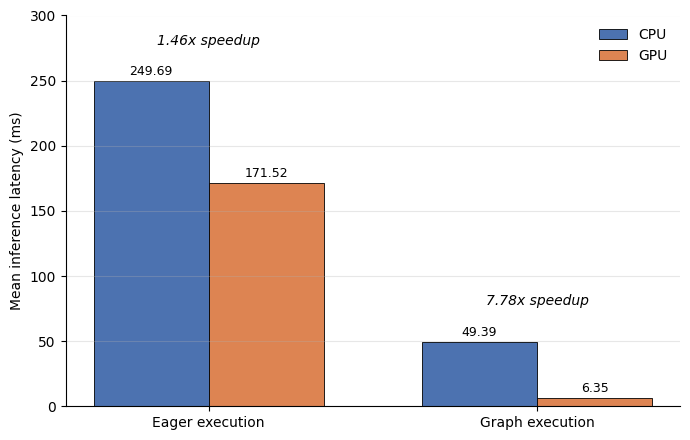

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cpu = [249.69, 49.39]
gpu = [171.52, 6.35]
speedup = [1.46, 7.78]
x, w = np.arange(2), 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w/2, cpu, w, label='CPU', color='#4C72B0', edgecolor='black', linewidth=0.6)
b2 = ax.bar(x + w/2, gpu, w, label='GPU', color='#DD8452', edgecolor='black', linewidth=0.6)
ax.bar_label(b1, fmt='%.2f', fontsize=9, padding=2)
ax.bar_label(b2, fmt='%.2f', fontsize=9, padding=2)

for i, s in enumerate(speedup):
    ax.text(i, max(cpu[i], gpu[i]) + 28, f'{s:.2f}x speedup',
            ha='center', fontsize=10, style='italic')

ax.set_ylabel('Mean inference latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels(['Eager execution', 'Graph execution'])
ax.set_ylim(0, 300)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure_8_8.png', dpi=300, bbox_inches='tight')
plt.show()

         count       mean        std        min        25%        50%  \
device                                                                  
CPU     1000.0  49.387147  14.630267  38.014709  40.654038  42.216473   
GPU     1000.0   6.351403   3.512943   4.892365   5.488416   5.652162   

              75%         max  
device                         
CPU     49.798221  171.734154  
GPU      5.856632   39.752061  


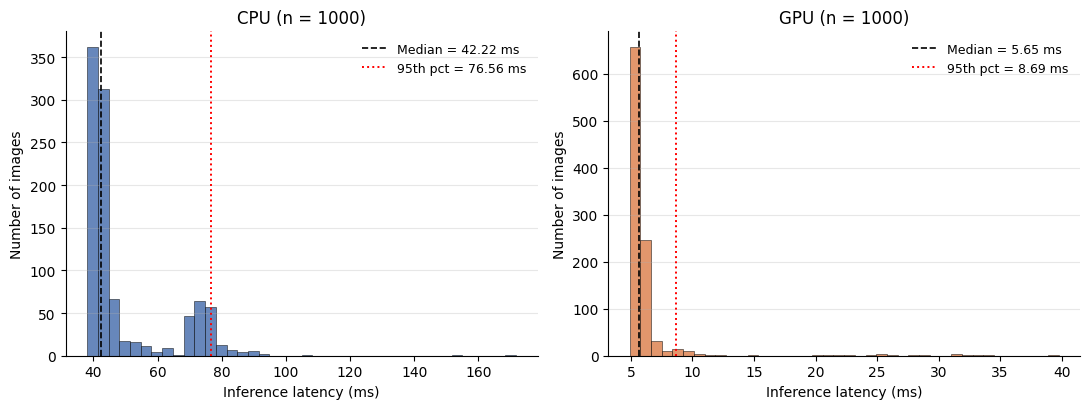

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

PROJECT_ID = 'keen-scion-504005-c4'
DATASET_ID = 'GC_ID'
client = bigquery.Client(project=PROJECT_ID)

d = client.query(f'''
SELECT 'CPU' AS device, latency_ms FROM `{PROJECT_ID}.{DATASET_ID}.CPU_Predictions`
UNION ALL
SELECT 'GPU' AS device, latency_ms FROM `{PROJECT_ID}.{DATASET_ID}.GPU_Predictions`
''').to_dataframe(create_bqstorage_client=False)

print(d.groupby('device')['latency_ms'].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (dev, colour) in zip(axes, [('CPU', '#4C72B0'), ('GPU', '#DD8452')]):
    v = d.loc[d.device == dev, 'latency_ms'].values
    ax.hist(v, bins=40, color=colour, edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.axvline(np.median(v), color='black', ls='--', lw=1.2,
               label=f'Median = {np.median(v):.2f} ms')
    ax.axvline(np.percentile(v, 95), color='red', ls=':', lw=1.4,
               label=f'95th pct = {np.percentile(v, 95):.2f} ms')
    ax.set_title(f'{dev} (n = {len(v)})')
    ax.set_xlabel('Inference latency (ms)')
    ax.set_ylabel('Number of images')
    ax.legend(frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure_8_15.png', dpi=300, bbox_inches='tight')
plt.show()